# Airline Passenger Satisfaction Prediction

## Data Cleaning & Exploratory Data Analysis

### Objective

This notebook is the first step for the airline satisfaction project. I'm using the Invistico Airline dataset, which has around 130k passenger survey responses covering things like flight details, service ratings, and whether the passenger was satisfied overall.

Here I'm loading the data, cleaning it up, and exploring the relationships between passenger demographics, flight details, service ratings, and satisfaction. The goal is to get a clear picture of what actually separates satisfied passengers from dissatisfied ones before moving on to feature engineering and modeling.

**Dataset overview:**
- **Target:** satisfaction (satisfied / dissatisfied)
- **Demographics:** age, gender, customer type, type of travel, class
- Flight distance
- 14 service-quality ratings (0-5 scale)
- Departure and arrival delay (in minutes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


### Load the raw data

In [2]:
df = pd.read_csv("../data/raw/Invistico_Airline.csv")
print("Shape:", df.shape)
df.head()


Shape: (129880, 23)


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction,129880,2,satisfied,71087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,129880,2,Female,65899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,129880,2,Loyal Customer,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Type of Travel,129880,2,Business travel,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,129880.0,NaN,NaN,NaN,1981.409055,1027.115606,50.0,1359.0,1925.0,2544.0,6951.0
Seat comfort,129880.0,NaN,NaN,NaN,2.838597,1.392983,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,NaN,NaN,NaN,2.990645,1.527224,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,NaN,NaN,NaN,2.851994,1.443729,0.0,2.0,3.0,4.0,5.0


A few things stood out to me here:

- Most passengers are traveling for business and most are loyal customers so the dataset is pretty skewed toward "regular business travelers" rather than being an even mix. Worth keeping in mind for later, the model might end up more confident about business travelers just because there's way more data on them.
- Looking at the service ratings, seat comfort (2.84) and food and drink (2.85) have the lowest average scores, while cleanliness (3.71) and baggage handling (3.70) score the highest. So there might already be a hint here about which parts of the experience passengers are least happy with overall.
- The delay columns are wild, median delay is 0 minutes for both departure and arrival, but the max goes up to 1592 minutes (over 26 hours). That's a huge right skew, so I'll need to be careful with how I visualize these later (a regular boxplot is going to be basically unreadable with outliers like that).

In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Arrival Delay in Minutes    393
dtype: int64

Duplicate rows: 0


393 missing values, all in Arrival Delay in Minutes, and no duplicate rows at all. 393 out of ~130k rows is a tiny fraction (about 0.3%), so I'm comfortable just dropping those rows instead of trying to fill them in with something like the median. It shouldn't have any real effect on the analysis.

In [6]:
missing_pct = df.isnull().sum().sum() / len(df) * 100
print(f"Total missing values represent {missing_pct:.3f}% of rows")

df = df.dropna().reset_index(drop=True)
print("Shape after dropping missing values:", df.shape)


Total missing values represent 0.303% of rows
Shape after dropping missing values: (129487, 23)


satisfied       70882
dissatisfied    58605
Name: satisfaction, dtype: int64
satisfied       54.74063
dissatisfied    45.25937
Name: satisfaction, dtype: float64


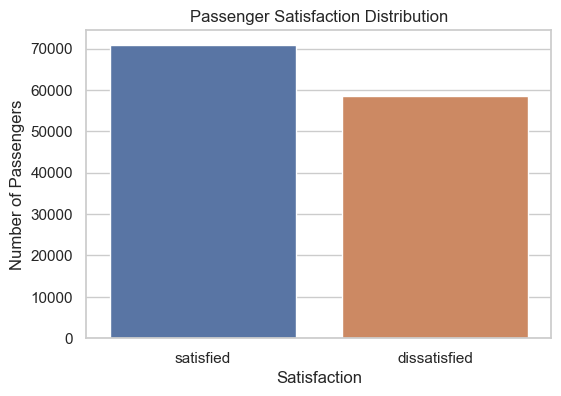

In [7]:
print(df["satisfaction"].value_counts())
print(df["satisfaction"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="satisfaction")
plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
plt.savefig("../images/satisfaction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Demographics vs. satisfaction

Checking whether gender, customer type (loyal vs. disloyal), travel type (business vs. personal), and class relate to satisfaction.

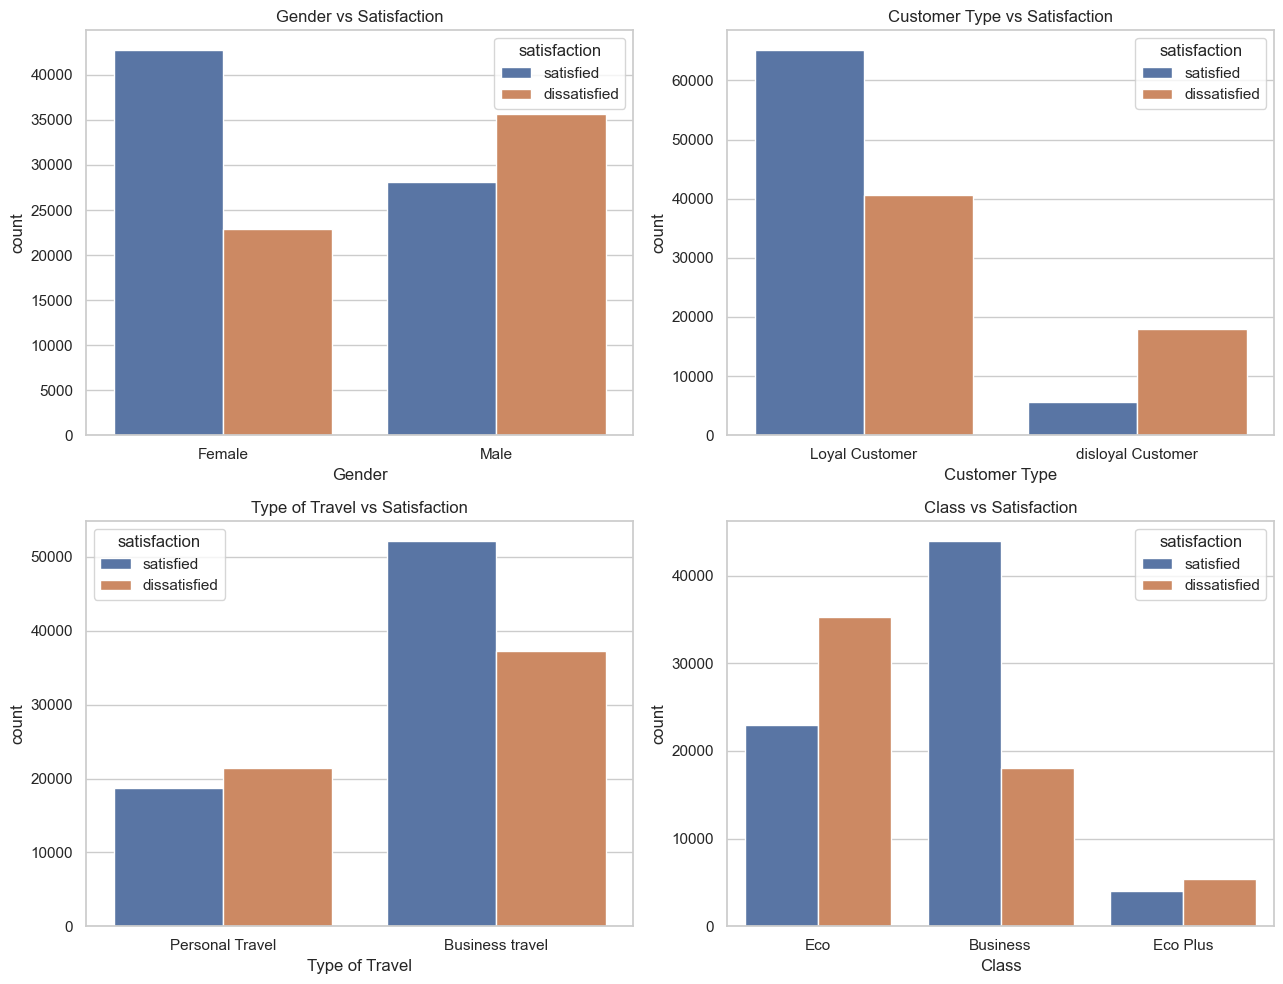

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.countplot(data=df, x="Gender", hue="satisfaction", ax=axes[0, 0])
axes[0, 0].set_title("Gender vs Satisfaction")

sns.countplot(data=df, x="Customer Type", hue="satisfaction", ax=axes[0, 1])
axes[0, 1].set_title("Customer Type vs Satisfaction")

sns.countplot(data=df, x="Type of Travel", hue="satisfaction", ax=axes[1, 0])
axes[1, 0].set_title("Type of Travel vs Satisfaction")

sns.countplot(data=df, x="Class", hue="satisfaction", ax=axes[1, 1])
axes[1, 1].set_title("Class vs Satisfaction")

plt.tight_layout()
plt.savefig("../images/demographics_vs_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()


Observations:

- **Gender:** Females lean satisfied, males lean dissatisfied which is not a huge gap, but noticeable enough that gender might be worth keeping as a feature.
- **Customer Type:** Loyal customers are mostly satisfied, but disloyal customers are overwhelmingly dissatisfied (way more dissatisfied than satisfied). Customer type looks like it could be one of the stronger predictors here.
- **Type of Travel:** Business travelers mostly satisfied, personal travelers mostly dissatisfied. Makes sense as business travel probably comes with more amenities and a different set of expectations.
- **Class:** Business class passengers are mostly satisfied, Economy passengers are mostly dissatisfied, and Economy Plus is close to a toss-up. So class matters, and it lines up with the Type of Travel pattern (business travelers are probably more likely to be flying Business class in the first place).

So overall, customer type, travel type, and class all look like they're good feature, not just noise.

### Age and Flight Distance vs. satisfaction

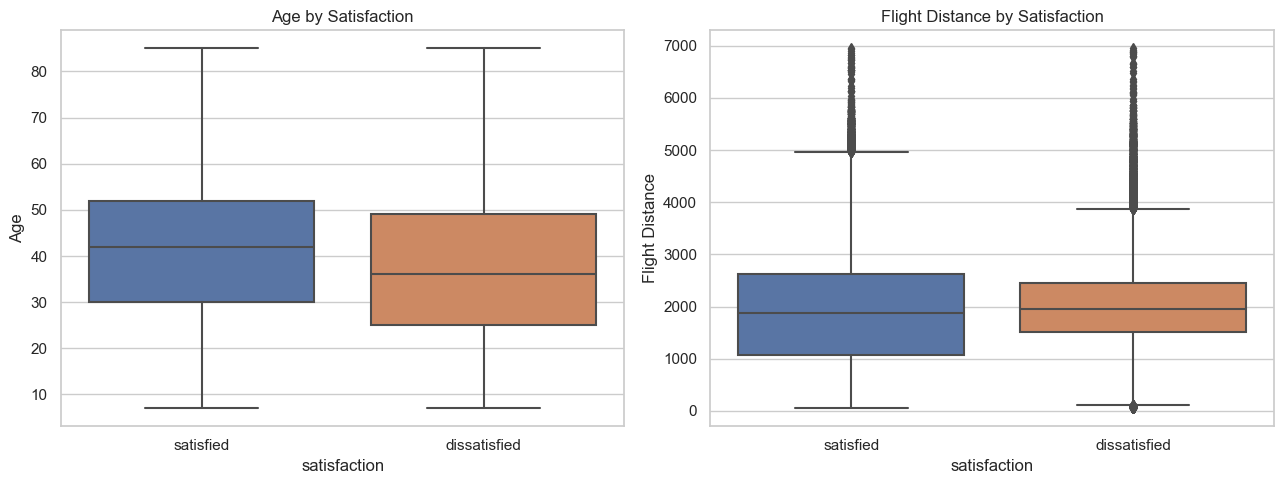

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="satisfaction", y="Age", ax=axes[0])
axes[0].set_title("Age by Satisfaction")

sns.boxplot(data=df, x="satisfaction", y="Flight Distance", ax=axes[1])
axes[1].set_title("Flight Distance by Satisfaction")

plt.tight_layout()
plt.savefig("../images/age_distance_vs_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()


Age-wise, satisfied passengers skew a little older (median around 41) compared to dissatisfied passengers (median around 36) not a massive gap, but it's there. Flight distance looks pretty similar between the two groups though, so I don't think that one's doing much on its own.

### Service ratings vs. satisfaction

Rather than 14 separate individual charts, the mean rating for each service category is compared side-by-side across satisfied vs. dissatisfied passengers, a faster way to see which specific service aspects separate the two groups most.

In [10]:
service_cols = [
    "Seat comfort", "Departure/Arrival time convenient", "Food and drink",
    "Gate location", "Inflight wifi service", "Inflight entertainment",
    "Online support", "Ease of Online booking", "On-board service",
    "Leg room service", "Baggage handling", "Checkin service",
    "Cleanliness", "Online boarding"
]

service_means = df.groupby("satisfaction")[service_cols].mean().T
service_means["gap"] = service_means["satisfied"] - service_means["dissatisfied"]
service_means = service_means.sort_values("gap", ascending=False)

service_means


satisfaction,dissatisfied,satisfied,gap
Inflight entertainment,2.609044,4.024266,1.415222
Ease of Online booking,2.851873,3.985031,1.133159
Online support,2.959833,3.983085,1.023252
On-board service,2.972818,3.872196,0.899378
Online boarding,2.869653,3.751799,0.882146
Leg room service,3.052555,3.844587,0.792032
Seat comfort,2.467315,3.145552,0.678237
Checkin service,2.971845,3.645721,0.673876
Baggage handling,3.364269,3.969287,0.605018
Inflight wifi service,2.919922,3.521374,0.601452


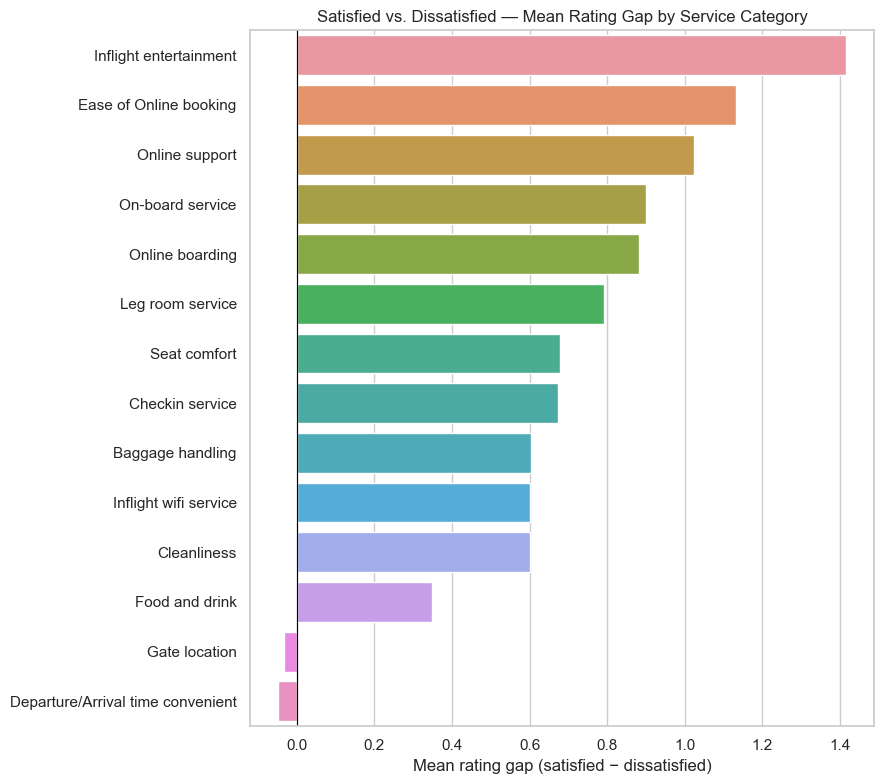

In [11]:
plt.figure(figsize=(9, 8))
sns.barplot(x=service_means["gap"], y=service_means.index, orient="h")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Satisfied vs. Dissatisfied — Mean Rating Gap by Service Category")
plt.xlabel("Mean rating gap (satisfied − dissatisfied)")
plt.tight_layout()
plt.savefig("../images/service_rating_gaps.png", dpi=300, bbox_inches="tight")
plt.show()


This is probably the most useful chart so far. Inflight entertainment has by far the biggest gap (1.42) between satisfied and dissatisfied passengers, followed by ease of online booking (1.13) and online support (1.02). Those three stand out clearly from the rest.

On the flip side, gate location and departure/arrival time convenience both come in basically at zero (even slightly negative), meaning satisfied and dissatisfied passengers rated those about the same. That's a little surprising, I would've expected timing/gate stuff to matter more but the data's saying otherwise, so I'll trust it over my assumption.

### Delay features vs. satisfaction

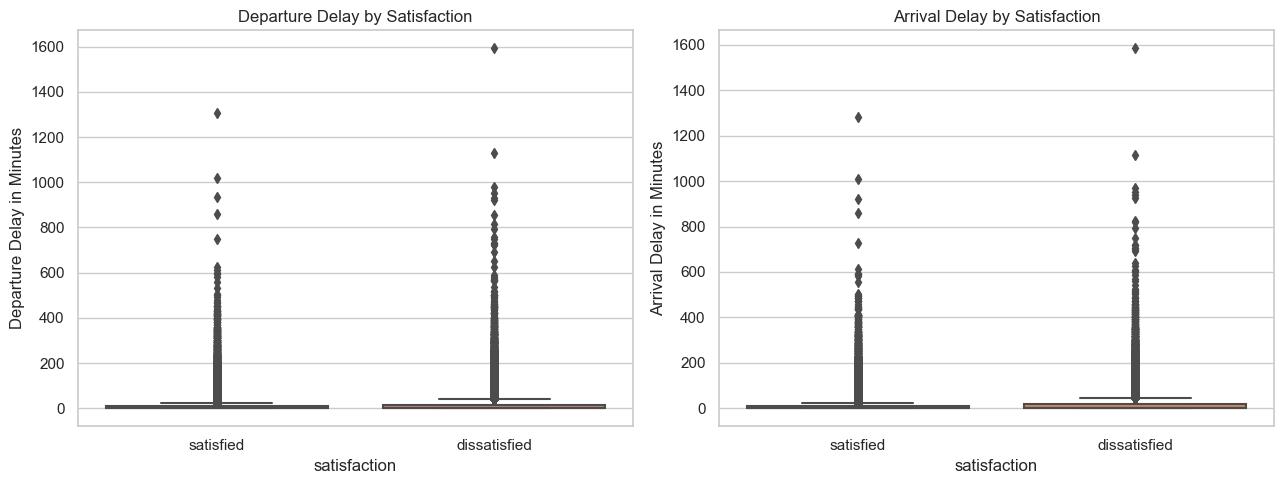

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="satisfaction", y="Departure Delay in Minutes", ax=axes[0])
axes[0].set_title("Departure Delay by Satisfaction")

sns.boxplot(data=df, x="satisfaction", y="Arrival Delay in Minutes", ax=axes[1])
axes[1].set_title("Arrival Delay by Satisfaction")

plt.tight_layout()
plt.savefig("../images/delay_vs_satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()


Both Departure Delay and Arrival Delay look almost identical between satisfied and dissatisfied passengers, with the boxes themselves squashed flat near zero and a long column of outlier dots stretching up past 1500 minutes. The scale is so dominated by those extreme outliers that I can't actually tell if there's a real difference between the two groups just from looking at this. I'd need to zoom in or cap the range to see anything useful.

       Departure Delay in Minutes  Arrival Delay in Minutes
count               129487.000000             129487.000000
mean                    14.643385                 15.091129
std                     37.932867                 38.465650
min                      0.000000                  0.000000
25%                      0.000000                  0.000000
50%                      0.000000                  0.000000
75%                     12.000000                 13.000000
max                   1592.000000               1584.000000


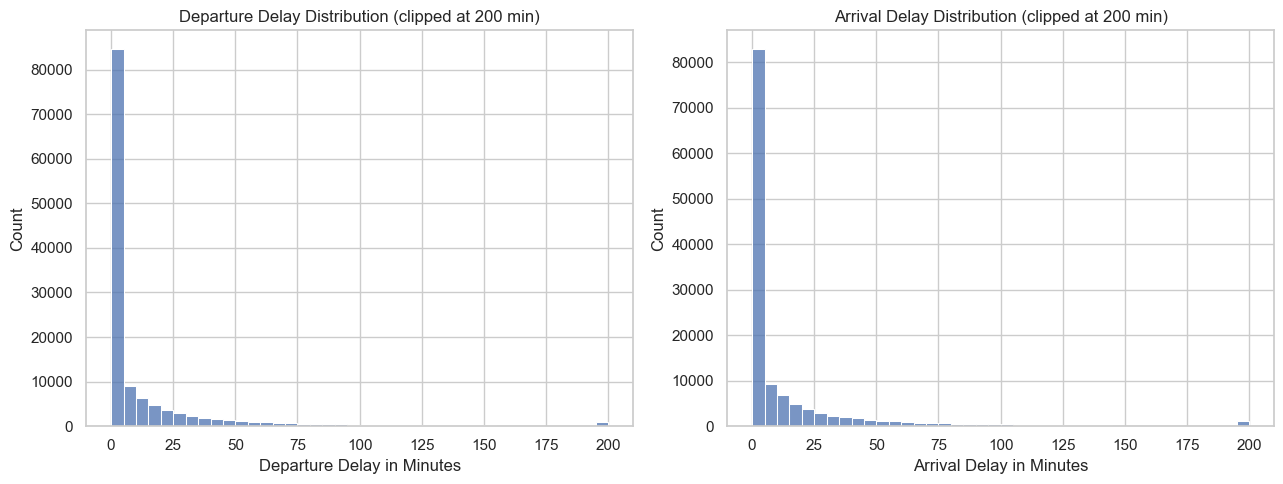

In [13]:
print(df[["Departure Delay in Minutes", "Arrival Delay in Minutes"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["Departure Delay in Minutes"].clip(upper=200), bins=40, ax=axes[0])
axes[0].set_title("Departure Delay Distribution (clipped at 200 min)")

sns.histplot(df["Arrival Delay in Minutes"].clip(upper=200), bins=40, ax=axes[1])
axes[1].set_title("Arrival Delay Distribution (clipped at 200 min)")

plt.tight_layout()
plt.savefig("../images/delay_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


The boxplots don't show an obvious difference between satisfied and dissatisfied passengers for either delay column, both groups have that same long tail of extreme outliers. I'll hold off on a final call until I check the correlation numbers below, but visually delays don't look like they're doing much here.

### Correlation matrix (numeric features)

satisfaction is temporarily encoded as a 0/1 numeric column for this correlation check only, the main dataframe keeps the original text labels for readability elsewhere in this notebook.

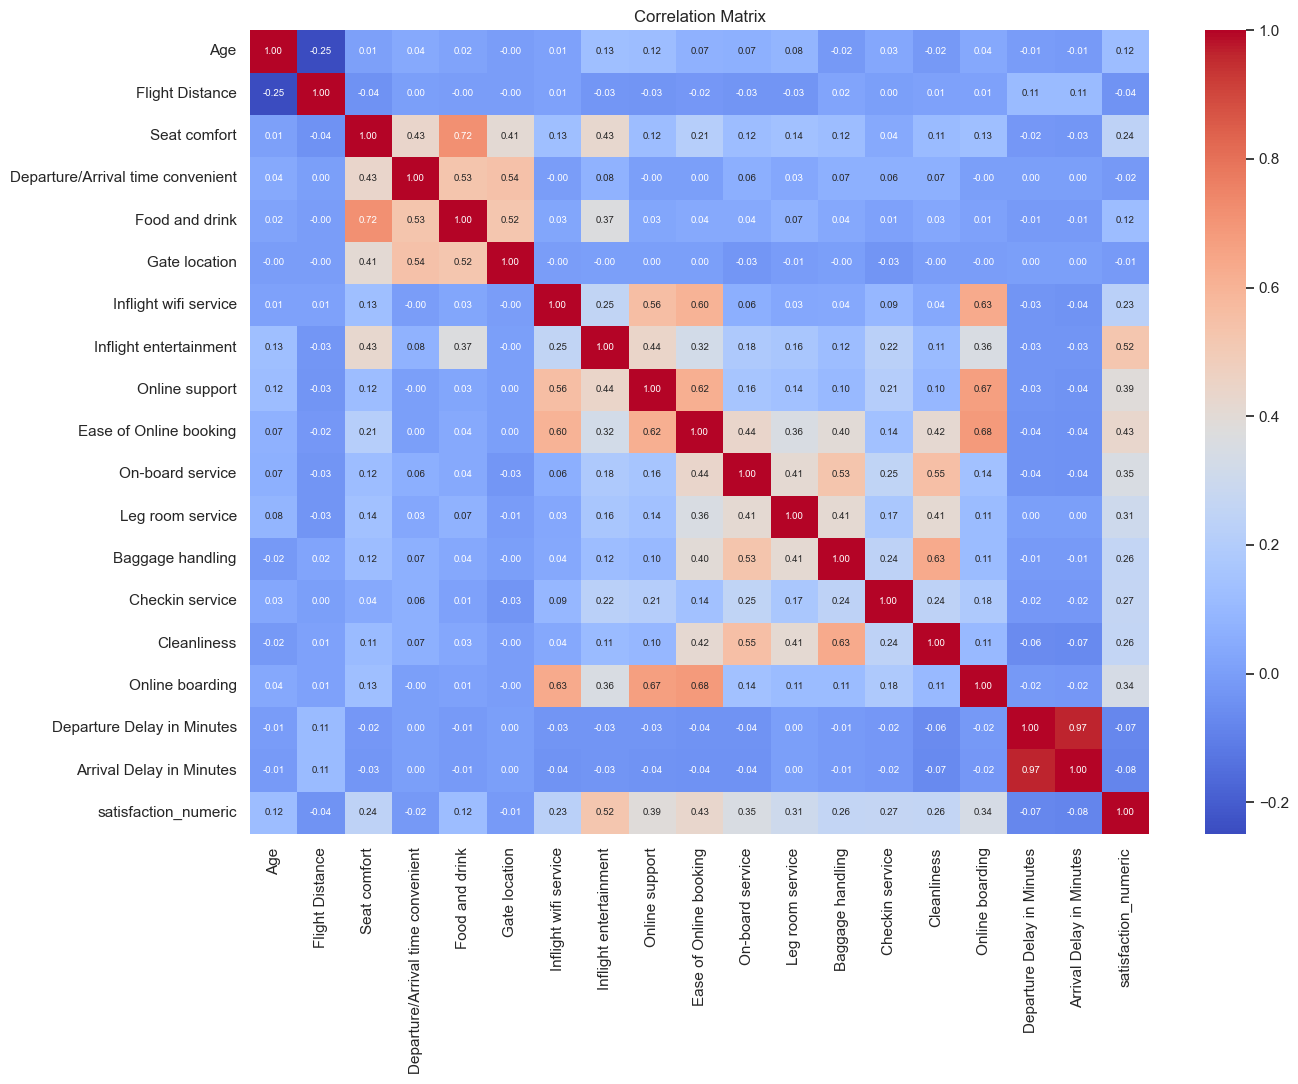

In [15]:
df_corr = df.copy()
df_corr["satisfaction_numeric"] = (df_corr["satisfaction"] == "satisfied").astype(int)

numeric_cols = df_corr.select_dtypes(include=np.number).columns
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../images/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
corr_matrix["satisfaction_numeric"].sort_values(ascending=False)


satisfaction_numeric                 1.000000
Inflight entertainment               0.523364
Ease of Online booking               0.432017
Online support                       0.389890
On-board service                     0.352283
Online boarding                      0.338118
Leg room service                     0.305115
Checkin service                      0.266089
Baggage handling                     0.260398
Cleanliness                          0.259504
Seat comfort                         0.242371
Inflight wifi service                0.227010
Food and drink                       0.120568
Age                                  0.117913
Gate location                       -0.012272
Departure/Arrival time convenient   -0.015624
Flight Distance                     -0.039133
Departure Delay in Minutes          -0.073960
Arrival Delay in Minutes            -0.080691
Name: satisfaction_numeric, dtype: float64

This backs up what I was seeing in the earlier charts. Inflight entertainment (0.52), ease of online booking (0.43), online support (0.39), on-board service (0.35), and online boarding (0.34) are the strongest correlates with satisfaction. Basically the same top categories from the service rating gap chart, just in a slightly different order.

Age has a weak positive correlation (0.12), which matches the boxplot from earlier. And interestingly, both delay columns actually show a small *negative* correlation with satisfaction (-0.07 and -0.08) so longer delays are weakly associated with being dissatisfied, which is what I'd expect, but it's a much weaker relationship than I assumed going in. The service ratings are doing way more of the heavy lifting here than delays are.

One more thing I noticed in the heatmap: some of the service rating columns are pretty correlated with each other (like departure/arrival time convenient and food and drink at 0.72, or ease of online booking and online boarding at 0.68). And obviously departure delay and arrival delay are almost perfectly correlated with each other (0.97), which makes sense since one usually causes the other. I'll keep this in mind for feature engineering, might not need both delay columns separately.

### Save the cleaned dataset

In [17]:
df.to_csv("../data/processed/airline_satisfaction_clean.csv", index=False)
print("Saved cleaned dataset:", df.shape)


Saved cleaned dataset: (129487, 23)


## Key Findings

- **Target balance:** satisfaction is pretty close to balanced (about 55% satisfied, 45% dissatisfied). That's good news
  for modeling since it means accuracy should actually be a reasonable metric to use later.
- **Strongest service drivers:** inflight entertainment, ease of online booking, and online support stand out clearly, both in the rating-gap chart and in the correlation matrix. These are the service categories most worth focusing on.
- **Weakest/irrelevant features:** gate location and departure/arrival time convenience barely separate satisfied from dissatisfied passengers at all, close to zero correlation either way. Flight distance also looks pretty weak on its own.
- **Class and travel type matter:** business class and business travel both lean satisfied, while economy and personal travel lean dissatisfied. Customer type (loyal vs. disloyal) shows an even bigger split.
- **Delays matter less than I expected:** I went in assuming delays would be a big driver of dissatisfaction, but the correlation is weak (around -0.07 to -0.08). The service experience itself seems to matter a lot more than how late the flight was.
- **Some service ratings are correlated with each other:** a few pairs of service columns (like the two delay columns, or ease of online booking and online boarding) move together pretty strongly. Worth keeping in mind for feature engineering as I might not need to keep every single one as a separate feature.

**Next step:** encode the categorical columns (gender, customer type, type of travel, class), and look at whether it's worth combining the two delay columns into one, since they're so highly correlated with each other.
